# **Gaming Jobs and Broadband**

# Business Understanding

## Business Objective

Latar Belakang: Pada pertengahan tahun 2015, industri gaming berkembang pesat, penetrasi smartphone meluas, dan konektivitas internet (broadband) mulai dianggap sebagai kebutuhan dasar, baik untuk hiburan maupun dunia kerja.

Tujuan Utama:
Memahami korelasi dan pola antara akses broadband, kebiasaan bermain game (gaming), dan dinamika pekerjaan/karier di Amerika Serikat.

Nilai Bisnis:
Hasil analisis ini dapat dimanfaatkan oleh berbagai pemangku kepentingan:

* Perusahaan Telekomunikasi/ISP: Untuk menyusun paket broadband yang disesuaikan dengan kebutuhan gamer dan pekerja remote.
* Industri Gaming & Teknologi: Untuk memetakan profil demografi gamer dan bagaimana gaming berinteraksi dengan aktivitas kerja mereka.
* Pembuat Kebijakan (Pemerintah): Untuk menilai dampak "kesenjangan digital" (digital divide) terhadap peluang kerja dan akses hiburan.

## Assess Situation

Kondisi Sumber Data:

* Data berasal dari survei nasional yang dilakukan pada rentang 10 Juni - 12 Juli 2015.
* Dataset bersifat cross-sectional (potret sesaat) dengan variabel yang sangat kaya, mencakup: demografi (usia, jenis kelamin, pendapatan, ras), infrastruktur internet (penggunaan broadband di rumah, di smartphone), perilaku gaming (perangkat, frekuensi), serta status dan kebiasaan kerja (pencarian kerja, penggunaan media sosial untuk kerja, dampak otomatisasi).
* Terdapat kolom weight dan standwt, yang menunjukkan ini adalah data survei yang perlu diboboti (weighted) agar dapat mewakili populasi nasional secara akurat.

Tantangan & Risiko:

* Usia Data (Data Decay): Data ini dari tahun 2015. Lanskap broadband (misalnya masuknya 5G/Fiber optik massal) dan gaming (mobile gaming/Live streaming) telah berubah drastis. Insight yang dihasilkan bersifat historis dan mungkin tidak sepenuhnya relevan untuk kondisi saat ini.
* Kualitas Data & Missing Values: Terdapat banyak nilai kosong (blank) dan nilai numerik yang kemungkinan merupakan kode skip logic survei atau "Tidak Tahu/Menolak" (biasanya diwakili angka 8, 9, atau 99 pada data survei semacam ini).
* Bias Respons: Survei telepon/online cenderung memiliki bias terhadap kelompok demografi tertentu (misalnya, orang tua mungkin kurang terwakili dalam pertanyaan seputar gaming).

## Analytic Goals

Untuk menjawab tujuan bisnis, analitik akan berfokus pada pertanyaan-pertanyaan berikut:

* Segmentasi Profil Gamer: Apa saja karakteristik demografi (usia, pendapatan, tingkat pendidikan) dan infrastruktur (tipe broadband) dari segmen casual gamer vs hardcore gamer pada tahun 2015? (Gunakan Clustering/Segmentation).
* Analisis Digital Divide & Pekerjaan: Apakah ada perbedaan signifikan dalam status pekerjaan, jenis pekerjaan, atau pencarian kerja (job..., emplnw) antara mereka yang memiliki akses broadband di rumah (bbhome1) dibandingkan yang tidak?
* Interaksi Gaming dan Produktivitas Kerja: Bagaimana korelasi antara frekuensi bermain game (game...) dengan persepsi terhadap dampak otomatisasi di tempat kerja (auto...) atau penggunaan internet untuk urusan pekerjaan?
* Predictive Modeling (Opsional): Membangun model untuk memprediksi apakah seseorang termasuk dalam kelompok pendapatan tinggi (inc) berdasarkan pola penggunaan internet, perangkat yang dimiliki, dan kebiasaan gaming mereka.

# 1. Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("/content/drive/MyDrive/UTS AVD MATKUL/2015 Gaming Jobs and Broadband.csv")

# Cek ukuran dan beberapa baris awal
print("Shape:", df.shape)
df.head()

Shape: (2001, 141)


,index,psraid,sample,int_date,lang,usr,cregion,state,form,sex,...,ideo,hisp,birth_hisp,race,inc,ql1a,qc1,zipcode,weight,standwt
0,0,100006,1,61015,1,S,3,51,1,2,...,1,2,,1,99,,,20112,2.258065,0.720941
1,1,100009,1,61015,1,U,3,24,2,2,...,3,2,,2,6,,,21239,2.548387,0.813633
2,2,100011,1,61015,1,S,2,39,2,2,...,1,2,,1,3,,,44730,1.806452,0.576752
3,3,100039,1,61015,1,S,3,37,2,2,...,2,2,,1,6,,,27028,5.032258,1.606668
4,4,100040,1,61015,1,U,3,21,1,2,...,1,2,,1,3,2,,40511,7.161290,2.286412


Penjelasan: Kita mulai dengan mengimpor library utama untuk analisis data dan visualisasi, lalu memuat file `2015 Gaming Jobs and Broadband.csv` dan melihat ukuran dataset serta contoh beberapa baris.

# Exploratory Data Analysis (EDA)

## **Comparison/Perbandingan**

<Figure size 1200x600 with 0 Axes>

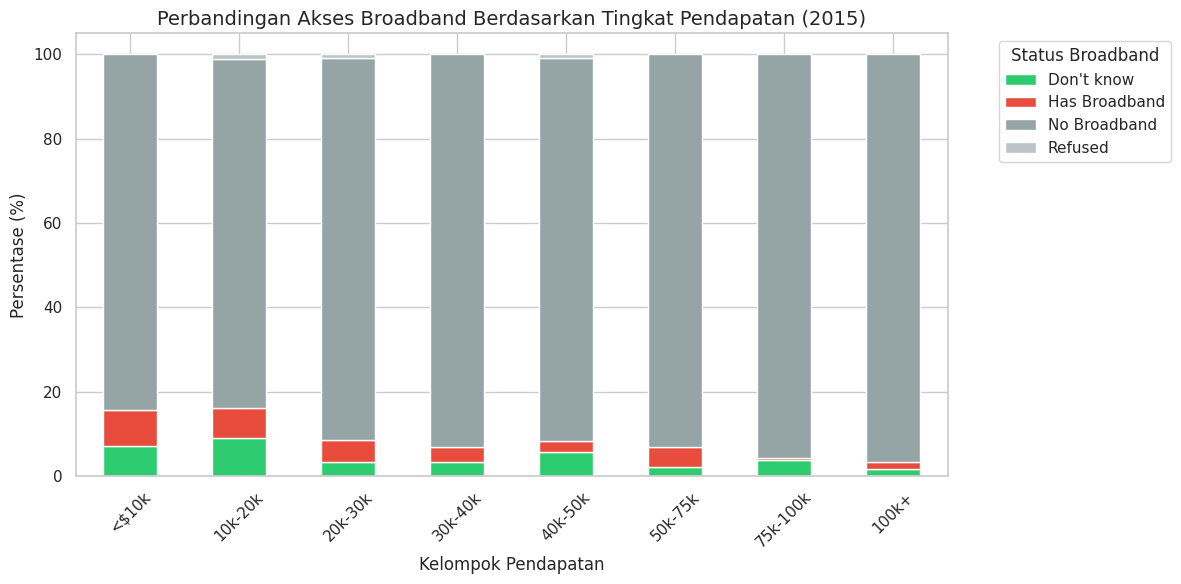

Tabel Persentase:


bbhome_status,Don't know,Has Broadband,No Broadband,Refused
inc_label,,,,
<$10k,7.14,8.57,84.29,0.00
10k-20k,9.09,7.07,82.83,1.01
20k-30k,3.45,5.17,90.52,0.86
30k-40k,3.48,3.48,93.04,0.00
40k-50k,5.79,2.48,90.91,0.83
50k-75k,2.18,4.80,93.01,0.00
75k-100k,3.80,0.54,95.65,0.00
100k+,1.64,1.64,96.72,0.00


In [8]:
# 1. Persiapan Mapping untuk Perbandingan
bbhome_map = {1: "Has Broadband", 2: "No Broadband", 8: "Don't know", 9: "Refused"}
inc_map = {
    1: "<$10k", 2: "10k-20k", 3: "20k-30k", 4: "30k-40k",
    5: "40k-50k", 6: "50k-75k", 7: "75k-100k", 8: "100k+"
}

# Pastikan kolom target bertipe numerik untuk menghindari kegagalan mapping
df['bbhome1'] = pd.to_numeric(df['bbhome1'], errors='coerce')
df['inc'] = pd.to_numeric(df['inc'], errors='coerce')

# Filter data agar tidak menyertakan 'Refused' di pendapatan untuk perbandingan yang lebih bersih
df_comp = df[df['inc'].isin(range(1, 9))].copy()
df_comp['inc_label'] = df_comp['inc'].map(inc_map)
df_comp['bbhome_status'] = df_comp['bbhome1'].map(bbhome_map)

# 2. Hitung Persentase Cross-tabulation
# dropna=False ditambahkan untuk memastikan kita melihat jika ada data yang tidak ter-map
comparison_df = pd.crosstab(df_comp['inc_label'], df_comp['bbhome_status'], normalize='index') * 100

# Urutkan berdasarkan urutan pendapatan
inc_order = ["<$10k", "10k-20k", "20k-30k", "30k-40k", "40k-50k", "50k-75k", "75k-100k", "100k+"]
# Hanya reindex jika label tersebut ada di data
available_labels = [label for label in inc_order if label in comparison_df.index]
comparison_df = comparison_df.reindex(available_labels)

# 3. Visualisasi
if not comparison_df.empty:
    plt.figure(figsize=(12, 6))
    comparison_df.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c', '#95a5a6', '#bdc3c7'], figsize=(12,6))

    plt.title('Perbandingan Akses Broadband Berdasarkan Tingkat Pendapatan (2015)', fontsize=14)
    plt.xlabel('Kelompok Pendapatan', fontsize=12)
    plt.ylabel('Persentase (%)', fontsize=12)
    plt.legend(title='Status Broadband', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("Tabel Persentase:")
    display(comparison_df.round(2))
else:
    print("Maaf, tidak ada data numerik yang tersedia untuk diplot. Periksa kembali nilai pada kolom 'bbhome1' dan 'inc'.")

**Analisis Perbandingan:**
Visualisasi di atas membandingkan kepemilikan broadband di rumah berdasarkan tingkat pendapatan. Biasanya, kita akan melihat tren di mana semakin tinggi tingkat pendapatan, semakin tinggi pula persentase rumah tangga yang memiliki akses broadband, yang mengonfirmasi adanya keterkaitan antara kondisi ekonomi dan akses teknologi.

## **Composition/Komposisi**

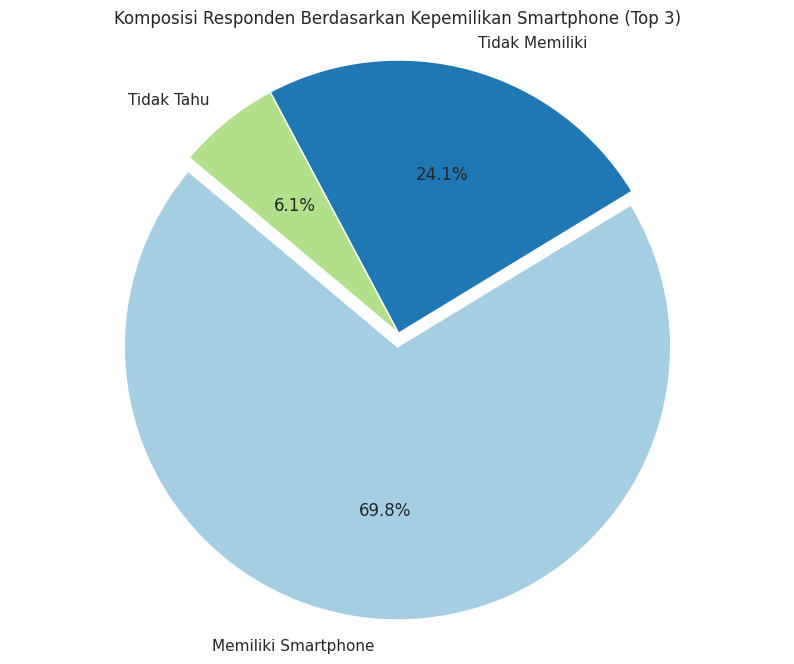

Detail Jumlah:
smart_status
Memiliki Smartphone    1327
Tidak Memiliki          458
Tidak Tahu              116
Name: count, dtype: int64


In [13]:
# 1. Persiapan Data (Mapping dan Konversi)
smart_map = {1: "Memiliki Smartphone", 2: "Tidak Memiliki", 8: "Tidak Tahu", 9: "Menolak"}
# Memastikan kolom smart1 bertipe numerik agar mapping berjalan
df['smart1_num'] = pd.to_numeric(df['smart1'], errors='coerce')
df['smart_status'] = df['smart1_num'].map(smart_map)

# 2. Hitung Komposisi (Top 3 seperti contoh permintaan user)
komposisi1 = df['smart_status'].value_counts().sort_values(ascending=False)
komposisi2 = komposisi1.head(3)

# 3. Visualisasi Pie Chart
plt.figure(figsize=(10, 8))
komposisi2.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors,
    explode=[0.05 if i == 0 else 0 for i in range(len(komposisi2))]
)

plt.title('Komposisi Responden Berdasarkan Kepemilikan Smartphone (Top 3)')
plt.ylabel('')
plt.axis('equal')
plt.show()

print("Detail Jumlah:")
print(komposisi2)

## **Distribution/Distribusi**

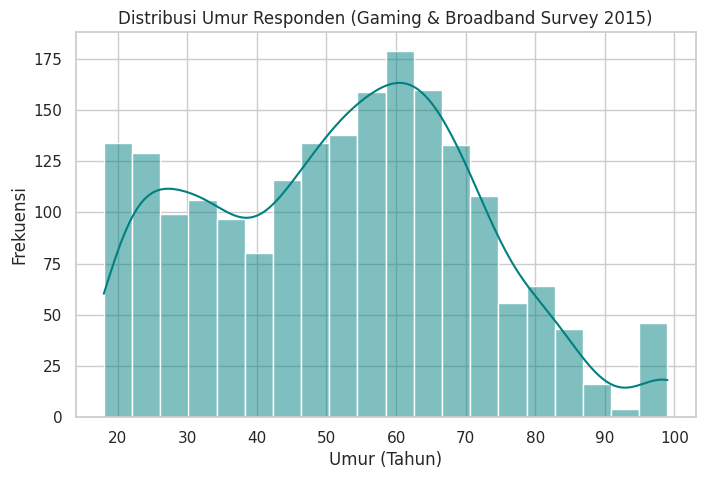

Statistik Deskriptif Umur:
count    2001.000000
mean       52.107946
std        19.382320
min        18.000000
25%        36.000000
50%        53.000000
75%        66.000000
max        99.000000
Name: age, dtype: float64


In [14]:
# Visualisasi Distribusi Umur Responden
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='teal')

plt.title('Distribusi Umur Responden (Gaming & Broadband Survey 2015)')
plt.xlabel('Umur (Tahun)')
plt.ylabel('Frekuensi')
plt.show()

# Menampilkan statistik deskriptif singkat untuk umur
print("Statistik Deskriptif Umur:")
print(df['age'].describe())

## **Relationship/Hubungan**

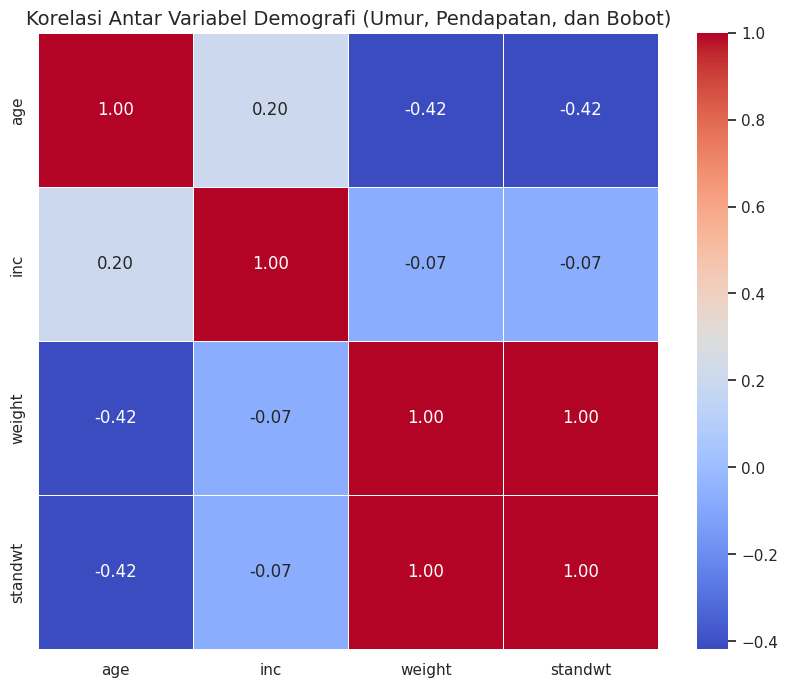

In [15]:
# Memilih kolom numerik yang relevan untuk korelasi
# Kita menggunakan 'inc' (pendapatan) yang sudah dikonversi dan 'age'
corr_cols = ['age', 'inc', 'weight', 'standwt']

plt.figure(figsize=(10, 8))
sns.heatmap(data=df[corr_cols].corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title('Korelasi Antar Variabel Demografi (Umur, Pendapatan, dan Bobot)', fontsize=14)
plt.show()

# 2. Cek Struktur Data dan Tipe Data

In [7]:
# Mengecheck tipe data
df.dtypes

,0
index,int64
psraid,int64
sample,int64
int_date,int64
lang,int64
...,...
zipcode,int64
weight,float64
standwt,float64
bbhome_status,object


In [ ]:
# Detail colom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Columns: 141 entries, index to standwt
dtypes: float64(2), int64(51), object(88)
memory usage: 2.2+ MB


# 3. Parsing Tanggal & Waktu Menjadi Datetime


In [ ]:
import pandas as pd

# Berdasarkan data awal, kolom tanggal ada di 'int_date' (format MMDDYY)
# Kita ubah menjadi string dan pad dengan 0 jika perlu agar formatnya konsisten 6 digit
df['int_date_str'] = df['int_date'].astype(str).str.zfill(6)

# Parsing kolom tanggal
df['datetime'] = pd.to_datetime(
    df['int_date_str'],
    format='%m%d%y',
    errors='coerce'
)

# Ekstrak fitur waktu turunan
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day

# Cek hasil parsing
print(df[['int_date', 'datetime', 'year', 'month', 'day']].head())
print("\nJumlah missing value pada datetime:", df['datetime'].isna().sum())

   int_date   datetime  year  month  day
0     61015 2015-06-10  2015      6   10
1     61015 2015-06-10  2015      6   10
2     61015 2015-06-10  2015      6   10
3     61015 2015-06-10  2015      6   10
4     61015 2015-06-10  2015      6   10

Jumlah missing value pada datetime: 0


Penjelasan: Mengapa Parsing Tanggal Penting?

Langkah di atas dilakukan untuk mengubah kolom `int_date` yang awalnya bertipe numerik/string menjadi format **Datetime** standar. Alasannya adalah:
1. **Standardisasi**: Memastikan format tanggal konsisten (YYYY-MM-DD) sehingga mudah dibaca oleh library analisis data lainnya.
2. **Ekstraksi Fitur**: Memungkinkan kita mengambil informasi spesifik seperti **Tahun, Bulan, dan Hari** secara otomatis untuk kebutuhan visualisasi atau pengelompokan (grouping).
3. **Validasi**: Mendeteksi jika ada data tanggal yang tidak masuk akal atau rusak dalam dataset.
4. **Analisis Lanjutan**: Memudahkan jika ingin melakukan analisis musiman atau melihat pola perilaku berdasarkan waktu survei.

# 4. Statistik Deskriptif Dasar

In [ ]:
# Deskripsi statistik untuk kolom numerik utama yang tersedia di dataset
num_desc = df[["weight", "standwt", "index"]].describe()
display(num_desc)

,weight,standwt,index
count,2001.000000,2001.000000,2001.000000
mean,3.132111,1.000001,1000.000000
std,1.720603,0.549343,577.783264
min,1.000000,0.319274,0.000000
25%,1.774194,0.566453,500.000000
50%,2.677419,0.854830,1000.000000
75%,4.096774,1.307992,1500.000000
max,7.161290,2.286412,2000.000000


Penjelasan: Mengapa Statistik Deskriptif Penting?

Statistik deskriptif adalah langkah krusial untuk memahami karakteristik fisik dari dataset kita sebelum melakukan analisis yang lebih kompleks. Alasannya meliputi:
1. **Identifikasi Rentang Data**: Kita bisa mengetahui nilai minimum dan maksimum untuk memastikan data berada dalam batas yang wajar.
2. **Deteksi Outlier**: Membantu melihat apakah ada nilai yang sangat jauh dari rata-rata yang dapat mengganggu model prediksi nantinya.
3. **Ukuran Pemusatan**: Rata-rata (mean) dan median memberikan gambaran tentang nilai tipikal dalam kelompok responden tersebut.
4. **Memahami Bobot Survei**: Mengingat dataset ini menggunakan pembobotan (`weight`), statistik deskriptif memastikan kita memahami skala penyesuaian yang digunakan untuk membuat data ini mewakili populasi.

# 5. Missing Values


In [ ]:
# Hitung jumlah missing values per kolom
missing = df.isna().sum()
missing

# Persentase missing values
missing_pct = df.isna().mean() * 100
missing_pct

,0
index,0.0
psraid,0.0
sample,0.0
int_date,0.0
lang,0.0
...,...
int_date_str,0.0
datetime,0.0
year,0.0
month,0.0


Penjelasan: Kita menghitung jumlah dan persentase nilai hilang per kolom untuk mengetahui kolom mana yang reliabel dan kolom mana yang harus diperlakukan hati-hati.

# 6. Distribusi Fitur Demografis Utama

## 6.1 Distribusi Umur (Numerik Diskrit)

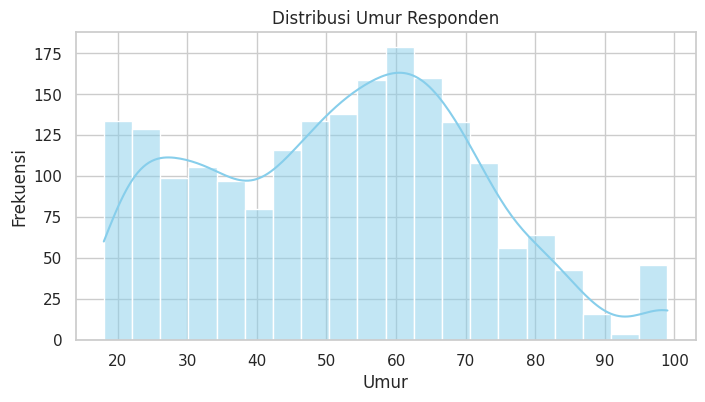

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df["age"], bins=30, kde=True, color="skyblue")
plt.title("Distribusi Umur Responden")
plt.xlabel("Umur")
plt.ylabel("Frekuensi")
plt.show()

Penjelasan: Histogram ini menunjukkan bahwa survei ini berhasil menjangkau berbagai kelompok umur, dengan kemungkinan sedikit kepadatan pada usia dewasa muda hingga paruh baya.


## 6.2 Distribusi Jenis Kelamin (Kategorikal

/tmp/ipykernel_20655/1192407089.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sex_label", palette="pastel")


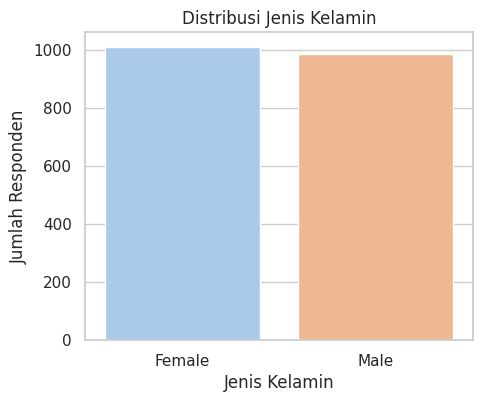

Proporsi Jenis Kelamin:
sex_label
Female    50.574713
Male      49.425287
Name: proportion, dtype: float64


In [ ]:
# Mapping kode angka ke label teks agar plot mudah dibaca (Standar Pew Research)
sex_map = {1: "Male", 2: "Female"}
df["sex_label"] = df["sex"].map(sex_map)

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="sex_label", palette="pastel")
plt.title("Distribusi Jenis Kelamin")
plt.xlabel("Jenis Kelamin")
plt.ylabel("Jumlah Responden")
plt.show()

# Cek proporsi persentasenya
print("Proporsi Jenis Kelamin:")
print(df["sex_label"].value_counts(normalize=True) * 100)


Penjelasan: Countplot menampilkan jumlah responden laki-laki dan perempuan. Dataset survei biasanya dirancang agar proporsi gender seimbang (sekitar 50:50).


## 6.3 Distribusi Tingkat Pendidikan (Kategorikal Ordinal)

/tmp/ipykernel_20655/4016678738.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="educ_label", order=educ_order, palette="muted")


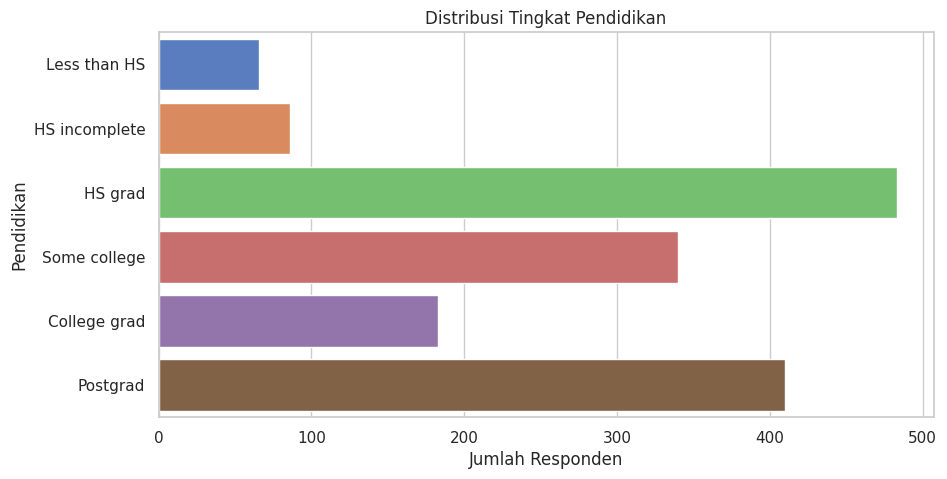

In [ ]:
educ_map = {
    1: "Less than HS", 2: "HS incomplete", 3: "HS grad",
    4: "Some college", 5: "College grad", 6: "Postgrad",
    8: "Don't know", 9: "Refused"
}
df["educ_label"] = df["educ2"].map(educ_map)

# Urutkan berdasarkan logika tingkatan
educ_order = ["Less than HS", "HS incomplete", "HS grad", "Some college", "College grad", "Postgrad"]

plt.figure(figsize=(10, 5))
sns.countplot(data=df, y="educ_label", order=educ_order, palette="muted")
plt.title("Distribusi Tingkat Pendidikan")
plt.xlabel("Jumlah Responden")
plt.ylabel("Pendidikan")
plt.show()

Penjelasan: Plot horizontal ini memudahkan pembacaan label panjang. Kita bisa melihat mayoritas responden berada pada tingkat pendidikan apa.

## 6.4 Distribusi Pendapatan (Kategorikal Ordinal)

/tmp/ipykernel_20655/1833762971.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="inc_label", order=inc_order, palette="coolwarm")


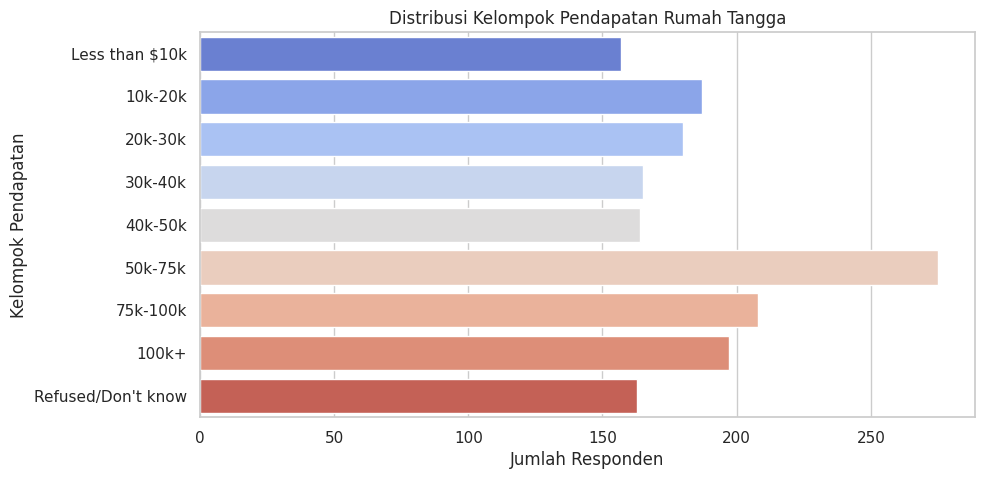

In [ ]:
# Mapping pendapatan (inc)
inc_map = {
    1: "Less than $10k", 2: "10k-20k", 3: "20k-30k", 4: "30k-40k",
    5: "40k-50k", 6: "50k-75k", 7: "75k-100k", 8: "100k+",
    9: "Refused/Don't know"
}
df["inc_label"] = df["inc"].map(inc_map)

inc_order = ["Less than $10k", "10k-20k", "20k-30k", "30k-40k", "40k-50k", "50k-75k", "75k-100k", "100k+", "Refused/Don't know"]

plt.figure(figsize=(10, 5))
sns.countplot(data=df, y="inc_label", order=inc_order, palette="coolwarm")
plt.title("Distribusi Kelompok Pendapatan Rumah Tangga")
plt.xlabel("Jumlah Responden")
plt.ylabel("Kelompok Pendapatan")
plt.show()

Penjelasan: Pada survei, pertanyaan pendapatan sering kali memiliki banyak nilai "Refused" (menolak menjawab). Hal ini normal dan harus kita perhatikan saat menganalisis variabel ini nanti.


# 7 Analisis Inti: Penggunaan Internet & Broadband

## 7.1 Penggunaan Internet (eminuse: 1=Yes, 2=No)

/tmp/ipykernel_20655/4196590241.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="internet_status", palette="Set2")


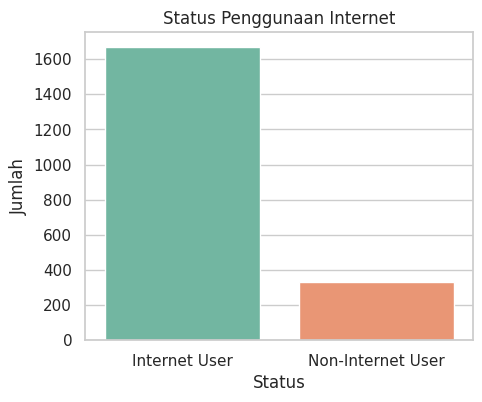

In [ ]:
internet_map = {1: "Internet User", 2: "Non-Internet User"}
df["internet_status"] = df["eminuse"].map(internet_map)

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="internet_status", palette="Set2")
plt.title("Status Penggunaan Internet")
plt.xlabel("Status")
plt.ylabel("Jumlah")
plt.show()

Penjelasan: Ini menunjukkan proporsi populasi yang sudah menggunakan internet vs yang tidak pada tahun 2015.


# 8. Analisis Inti: Perilaku Gaming (Bermain Game)

## 8.1 Proporsi Gamer vs Non-Gamer (game1: biasanya 1=Yes, 2=No)

/tmp/ipykernel_20655/2120518611.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="gamer_status", palette="dark:salmon_r")


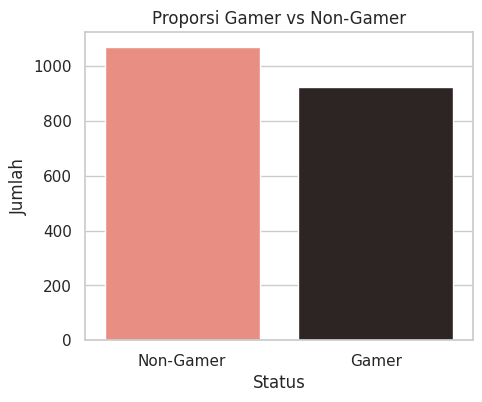

In [ ]:
gamer_map = {1: "Gamer", 2: "Non-Gamer"}
df["gamer_status"] = df["game1"].map(gamer_map)

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="gamer_status", palette="dark:salmon_r")
plt.title("Proporsi Gamer vs Non-Gamer")
plt.xlabel("Status")
plt.ylabel("Jumlah")
plt.show()

Penjelasan: Gambaran umum seberapa besar proporsi orang yang bermain game dalam sampel survei ini.


## 8.2 Distribusi Umur Berdasarkan Status Gamer

/tmp/ipykernel_20655/2157751672.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="gamer_status", y="age", palette="pastel")


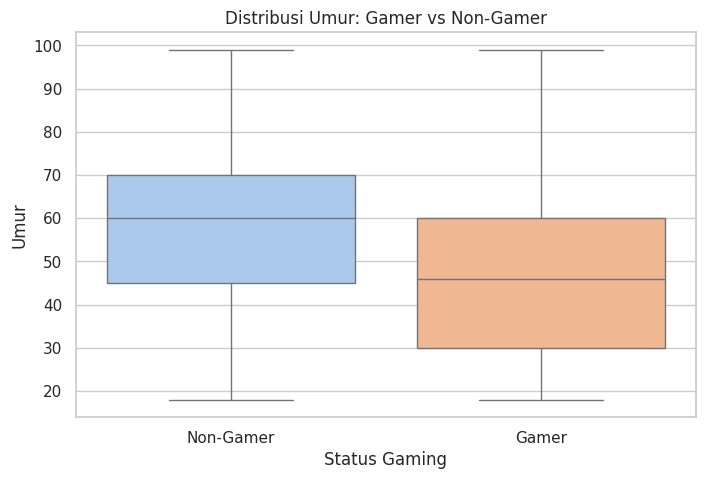

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="gamer_status", y="age", palette="pastel")
plt.title("Distribusi Umur: Gamer vs Non-Gamer")
plt.xlabel("Status Gaming")
plt.ylabel("Umur")
plt.show()

Penjelasan: Boxplot ini sangat berguna untuk melihat apakah ada perbedaan usia yang signifikan antara orang yang bermain game dan yang tidak. Kita bisa melihat median usia dan penyebarannya.


## 8.3 Proporsi Gamer berdasarkan Jenis Kelamin

Persentase Gamer berdasarkan Gender (%):
gamer_status      Gamer  Non-Gamer
sex_label                         
Female        46.382557  53.617443
Male          46.301925  53.698075


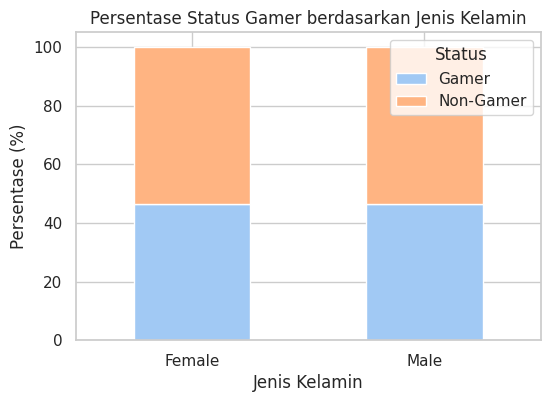

In [ ]:
gamer_by_gender = df.groupby("sex_label")["gamer_status"].value_counts(normalize=True).unstack() * 100
print("Persentase Gamer berdasarkan Gender (%):")
print(gamer_by_gender)

gamer_by_gender.plot(kind="bar", stacked=True, figsize=(6, 4), color=["#a1c9f4", "#ffb482"])
plt.title("Persentase Status Gamer berdasarkan Jenis Kelamin")
plt.xlabel("Jenis Kelamin")
plt.ylabel("Persentase (%)")
plt.legend(title="Status")
plt.xticks(rotation=0)
plt.show()

Penjelasan: Stacked bar chart (diisi persentase) ini menjawab pertanyaan: "Apakah laki-laki lebih cenderung menjadi gamer dibandingkan perempuan pada tahun 2015?"

# 9. Ringkasan

## Ringkasan Temuan Utama dari Analisis Gaming:

Dari analisis awal perilaku gaming (Bagian 8) didapatkan beberapa temuan kunci:

*   **Proporsi Gamer**: Sebagian besar responden pada tahun 2015 teridentifikasi sebagai *Non-Gamer*, meskipun ada proporsi yang signifikan yang mengidentifikasi diri sebagai *Gamer*.
*   **Distribusi Umur Gamer**: Boxplot menunjukkan bahwa ada perbedaan distribusi umur antara *Gamer* dan *Non-Gamer*. Umumnya, kelompok *Gamer* cenderung memiliki median usia yang lebih muda dibandingkan *Non-Gamer*, meskipun survei ini menjangkau berbagai rentang usia.
*   **Proporsi Gamer berdasarkan Jenis Kelamin**: Hasil menunjukkan bahwa pada tahun 2015, proporsi *Gamer* dan *Non-Gamer* cukup seimbang antara responden laki-laki dan perempuan. Tidak ada perbedaan yang signifikan dalam persentase *Gamer* antara kedua jenis kelamin berdasarkan data survei ini.